# 07MIAR - Redes Neuronales y Deep Learning: Proyecto de programación "*Deep Vision in classification tasks*"


## Enunciado

En esta actividad, el alumno debe **evaluar y comparar dos estrategias** para la **clasificación de imágenes** empleando el **dataset asignado**. Los alumnos deberá resolver el reto proponiendo una solución válida **basada en aprendizaje profundo**, más concretamente en redes neuronales convolucionales (**CNNs**). Será indispensable que la solución propuesta siga el **pipeline visto en clase** para resolver este tipo de tareas de inteligencia artificial:

1.   **Carga** del conjunto de datos
2.   **Inspección** del conjunto de datos
3.   **Acondicionamiento** del conjunto de datos
4.   Desarrollo de la **arquitectura** de red neuronal y **entrenamiento** de la solución
5.   **Monitorización** del proceso de **entrenamiento** para la toma de decisiones
6.   **Evaluación** del modelo predictivo y planteamiento de la siguiente prueba experimental

### Estrategia 1: Entrenar desde cero o *from scratch*

La primera estrategia a comparar será una **red neuronal profunda** que el **alumno debe diseñar, entrenar y optimizar**. Se debe **justificar empíricamente** las decisiones que llevaron a la selección de la **arquitectura e hiperparámetros final**. Se espera que el alumno utilice todas las **técnicas de regularización** mostradas en clase de forma justificada para la mejora del rendimiento de la red neuronal (*weight regularization*, *dropout*, *batch normalization*, *data augmentation*, etc.).

### Estrategia 2: Red pre-entrenada

La segunda estrategia a comparar debe incluir la utilización de una **red preentrenada** con el dataset ImageNet, llevando a cabo tareas de ***transfer learning*** y ***fine-tuning*** para resolver la tarea de clasificación asignada. Deben **compararse al menos dos tipos de arquitecturas** (VGGs, ResNet50, Xception, InceptionV3, InceptionResNetV2, MobileNetV2, DenseNet, ResNet) y se debe **seleccionar la que mayor precisión proporcione** (información sobre las arquitecturas disponibles en https://keras.io/applications/). Se espera el uso de todas las **técnicas de regularización** mostradas en clase de forma justificada para la mejora del rendimiento de la red neuronal (*weight regularization*, *dropout*, *batch normalization*, *data augmentation*, etc.).

## Normas a seguir

- Será **indispensable** realizar el **trabajo por parejas**. Dichas parejas de alumnxs se generarán **de manera automática** teniendo en cuenta el pais de residencia con el objetivo de facilitar el trabajo en equipo.  
- Se debe entregar un **ÚNICO FICHERO PDF POR ALUMNO** que incluya las instrucciones presentes en el Colab Noteboook y su **EJECUCIÓN!!!**. Debe aparecer todo el proceso llevado a cabo en cada estrategia (i.e. carga de datos, inspección de datos, acondicionamiento, proceso de entrenamiento y proceso de validación del modelo).
- **La memoria del trabajo** (el fichero PDF mencionado en el punto anterior) deberá **subirla cada integrante del grupo** (aunque se trate de un documento idéntico) a la actividad que se habilitará **en CampusVIU**.
- Se recomienda trabajar respecto a un directorio base (**BASE_FOLDER**) para facilitar el trabajo en equipo. En este notebook se incluye un ejemplo de cómo almacenar/cargar datos utilizando un directorio base.
- Las **redes propuestas** deben estar **entrenadas** (y **EVIDENCIAR este proceso en el documento PDF**). La entrega de una **red sin entrenar** supondrá **perdida de puntos**.
- Si se desea **evidenciar alguna métrica** del proceso de entrenamiento (precisión, pérdida, etc.), estas deben ser generadas.
- Todos los **gráficos** que se deseen mostrar deberán **generarse en el Colab Notebook** para que tras la conversión aparezcan en el documento PDF.

## *Tips* para realizar la actividad con éxito
- Los **datos** se cargarán directamente **desde** la plataforma **Kaggle** mediante su API (https://github.com/Kaggle/kaggle-api). En este Notebook se incluye un ejemplo de como hacerlo. Se recomienda generar una función que aborde esta tarea.
- El **documento PDF a entregar** como solución de la actividad se debe **generar automáticamente desde el fichero ".ipynb"**. En este Notebook se incluye un ejemplo de como hacerlo.
- **Generar secciones y subsecciones en el Colab Notebook** supondrá que el documento **PDF generado** queda totalmente **ordenado** facilitando la evaluación al docente.
- Se recomienda encarecidamente **incluir comentarios concisos pero aclaratorios**.
- Es muy recomendable crear una **última sección** de texto en el Colab Notebook en la que se discutan los diferentes modelos obtenidos y se extraigan las conclusiones pertinentes.

## Criterios de evaluación

- **Seguimiento** de las **normas establecidas** en la actividad (detalladas anteriormente).
- Creación de una **solución que resuelva la tarea de clasificación**, i.e. que las figuras de mérito empleadas para medir la bondad del modelo predictivo evidencien un *performance* superior al rendimiento estocástico.
- **Claridad** en la creación de la solución, en las justificaciones sobre la toma de decisiones llevada a cabo así como en las comparativas y conclusiones finales.
- **Efectividad** al presentar las comparaciones entre métricas de evaluación de ambas estrategias.
- **Demostración** de la utilización de **técnicas de regularización** para mejorar el rendimiento de los modelos.

# 1. Carga de datos

In [ ]:
# En primer lugar se debe generar un API de Kaggle personal, para ello:
#  1. Registrarse en  https://www.kaggle.com
#  2. Ir a 'Account tab' de tu perfil y seleccionar 'Create API Token'
#  3. Almacenar en tu ordenador local el fichero kaggle.json

In [ ]:
# Nos aseguramos que tenemos instalada la última versión de la API de Kaggle en Colab
!pip install --upgrade --force-reinstall --no-deps kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.2/181.2 kB 8.0 MB/s eta 0:00:00
  Attempting uninstall: kaggle
    Found existing installation: kaggle 1.7.4.5
    Uninstalling kaggle-1.7.4.5:
      Successfully uninstalled kaggle-1.7.4.5


In [ ]:
#%%capture
# Seleccionar el API Token personal previamente descargado (fichero kaggle.json)
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"peraltarh","key":"643e6d92ad594d1ff4e84cfdfa8a7b24"}'}

In [ ]:
# Creamos un directorio en el que copiamos el fichero kaggle.json
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Ya podemos listar los datasets disponibles en kaggle para su descarga
!kaggle datasets list

ref                                                             title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
ayeshaimran123/social-media-and-mental-health-balance           Social Media and Mental Health Balance                    5941  2025-10-26 07:51:53.380000           5414         75  1.0              
sadiajavedd/students-academic-performance-dataset               Students_Academic_Performance_Dataset                     8907  2025-10-23 04:16:35.563000           4740        113  1.0              
ayeshasiddiqa123/cars-pre                                       Car Price Analysis Dataset                               46557  2025-11-06 16:38:07.487000           1441         47  1.0              


In [ ]:
# IMPORTANTE ANTES DE DESCARGAR UN DATASET !!!
# Antes de descargar el dataset debemos ir a https://www.kaggle.com/c/$nameCompetition/data y aceptar las "Competition Rules"
# En caso de no realizar el paso anterior al descargar el dataset obtenedremos el siguiente mensaje "403 - Forbidden"
# AHORA SI: Descarguemos un dataset de cierta competición
#!kaggle competitions download -c vegetable-image-dataset
!kaggle datasets download -d misrakahmed/vegetable-image-dataset

#NOTA: El nombre del dataset de competición a descargar se informará en el documento en el que se presenten las parejas formadas

Dataset URL: https://www.kaggle.com/datasets/misrakahmed/vegetable-image-dataset
License(s): CC-BY-SA-4.0
 88% 469M/534M [00:02<00:00, 103MB/s]
100% 534M/534M [00:03<00:00, 186MB/s]


In [ ]:
# Creemos un directorio para descomprimir los datos
!mkdir my_dataset
# Conectamos con nuestro Google Drive
#from google.colab import drive
#drive.mount('/content/drive')


In [55]:
# Descomprimimos los datos y los dejamos listos para trabajar
BASE_FOLDER = "/content/my_dataset"



In [ ]:
#!unzip vegetable-image-dataset.zip -d my_dataset
!unzip "vegetable-image-dataset.zip" -d "{BASE_FOLDER}"

## Variables de ínteres

A continuación se declaran algunas variables que son de ínteres para el resto de los procesos

In [56]:
#%%capture
#!ls test/

TEST_DIR = BASE_FOLDER + "/Vegetable Images/test"
print("\n--- Directorio Test ---")
!ls "{TEST_DIR}"

TRAIN_DIR = BASE_FOLDER + "/Vegetable Images/train"
print("\n--- Directorio Train ---")
!ls "{TRAIN_DIR}"

VALIDATION_DIR = BASE_FOLDER + "/Vegetable Images/validation"
print("\n--- Directorio Validation ---")
!ls "{VALIDATION_DIR}"



--- Directorio Test ---
Bean	      Brinjal	Capsicum     Cucumber  Pumpkin
Bitter_Gourd  Broccoli	Carrot	     Papaya    Radish
Bottle_Gourd  Cabbage	Cauliflower  Potato    Tomato

--- Directorio Train ---
Bean	      Brinjal	Capsicum     Cucumber  Pumpkin
Bitter_Gourd  Broccoli	Carrot	     Papaya    Radish
Bottle_Gourd  Cabbage	Cauliflower  Potato    Tomato

--- Directorio Validation ---
Bean	      Brinjal	Capsicum     Cucumber  Pumpkin
Bitter_Gourd  Broccoli	Carrot	     Papaya    Radish
Bottle_Gourd  Cabbage	Cauliflower  Potato    Tomato


# 2. Inspección del conjunto de datos

In [ ]:
import os

def count_images_per_class(directory):
    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            num_images = len([f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))])
            print(f"{class_name}: {num_images} imatges")


In [ ]:
print("--- Train ---")
count_images_per_class(TRAIN_DIR)

print("\n--- Validation ---")
count_images_per_class(VALIDATION_DIR)

print("\n--- Test ---")
count_images_per_class(TEST_DIR)


--- Train ---
Bean: 1000 imatges
Capsicum: 1000 imatges
Pumpkin: 1000 imatges
Tomato: 1000 imatges
Potato: 1000 imatges
Brinjal: 1000 imatges
Radish: 1000 imatges
Cucumber: 1000 imatges
Papaya: 1000 imatges
Cauliflower: 1000 imatges
Bottle_Gourd: 1000 imatges
Cabbage: 1000 imatges
Carrot: 1000 imatges
Broccoli: 1000 imatges
Bitter_Gourd: 1000 imatges

--- Validation ---
Bean: 200 imatges
Capsicum: 200 imatges
Pumpkin: 200 imatges
Tomato: 200 imatges
Potato: 200 imatges
Brinjal: 200 imatges
Radish: 200 imatges
Cucumber: 200 imatges
Papaya: 200 imatges
Cauliflower: 200 imatges
Bottle_Gourd: 200 imatges
Cabbage: 200 imatges
Carrot: 200 imatges
Broccoli: 200 imatges
Bitter_Gourd: 200 imatges

--- Test ---
Bean: 200 imatges
Capsicum: 200 imatges
Pumpkin: 200 imatges
Tomato: 200 imatges
Potato: 200 imatges
Brinjal: 200 imatges
Radish: 200 imatges
Cucumber: 200 imatges
Papaya: 200 imatges
Cauliflower: 200 imatges
Bottle_Gourd: 200 imatges
Cabbage: 200 imatges
Carrot: 200 imatges
Broccoli: 200

**Comentarios**: Podemos apreciar que el dataset está muy bien balanceado, lo cual, denota que hay una buena representación de todas las clases implicadas en el proceso de clasificación. Con esto podemos descartar técnicas como over-sampling o under-sampling en el caso de este proyecto.

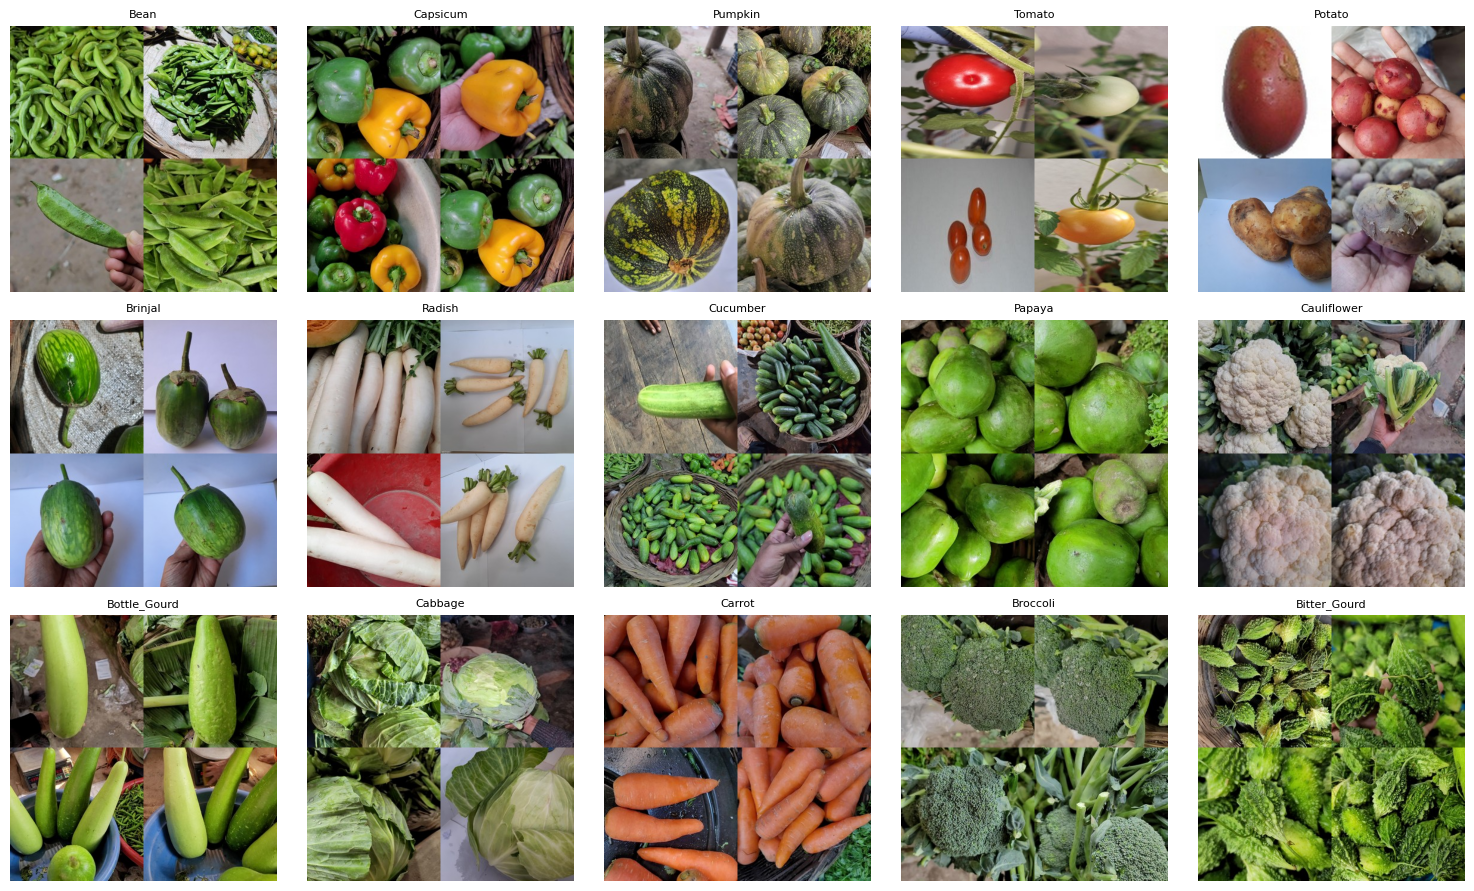

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random
import numpy as np

def Imagenes_ejemplo(directory, num_per_class=4, images_per_row=5):
    class_names = [d for d in os.listdir(directory) if os.path.isdir(os.path.join(directory, d))]
    total_classes = len(class_names)
    n_rows = int(np.ceil(total_classes / images_per_row))

    plt.figure(figsize=(images_per_row * 3, n_rows * 3))

    for idx, class_name in enumerate(class_names):
        class_path = os.path.join(directory, class_name)
        images = [f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))]
        samples = random.sample(images, min(num_per_class, len(images)))

        imgs = [mpimg.imread(os.path.join(class_path, img)) for img in samples]

        min_shape = np.min([img.shape for img in imgs], axis=0)
        imgs_resized = [img[:min_shape[0], :min_shape[1]] for img in imgs]

        top = np.hstack(imgs_resized[:2])
        bottom = np.hstack(imgs_resized[2:])
        mosaic = np.vstack([top, bottom])
        plt.subplot(n_rows, images_per_row, idx+1)
        plt.imshow(mosaic)
        plt.title(class_name, fontsize=8)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

Imagenes_ejemplo(TRAIN_DIR, num_per_class=4, images_per_row=5)




In [ ]:
from PIL import Image
import os
from collections import Counter

def check_image_sizes(directory):
    sizes = []

    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            for img_name in os.listdir(class_path):
                img_path = os.path.join(class_path, img_name)
                try:
                    img = Image.open(img_path)
                    sizes.append(img.size)  # (width, height)
                except:
                  print("No se puede abrir la imagen")
    size_counts = Counter(sizes)

    print("--- Tamaños de imagenes ---")
    for size, count in size_counts.items():
        print(f"{size}: {count} imagenes")

    print(f"\nTotal de imagenes: {sum(size_counts.values())}")


check_image_sizes(TRAIN_DIR)


--- Tamaños de imagenes ---
(224, 224): 14994 imagenes
(224, 211): 1 imagenes
(224, 210): 1 imagenes
(224, 198): 1 imagenes
(224, 205): 1 imagenes
(224, 200): 1 imagenes
(224, 193): 1 imagenes

Total de imagenes: 15000


Viendo que solo hay 6 imagenes de un total de 15.000 con un tamaño distinto, las eliminamos del conjunto de train para evitar distorsiones.


In [ ]:
import shutil

TRAIN_DIR = BASE_FOLDER + "/Vegetable Images/train"
DISCARD_DIR = BASE_FOLDER + "/Vegetable Images/train_descartadas"
os.makedirs(DISCARD_DIR, exist_ok=True)

for class_name in os.listdir(TRAIN_DIR):
    class_path = os.path.join(TRAIN_DIR, class_name)
    if os.path.isdir(class_path):
        discard_class_path = os.path.join(DISCARD_DIR, class_name)
        os.makedirs(discard_class_path, exist_ok=True)

        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            try:
                img = Image.open(img_path)
                if img.size != (224, 224):
                    shutil.move(img_path, os.path.join(discard_class_path, img_name))
            except:
                print(f"No se puede abrir la imagen: {img_path}")


In [ ]:
# Volvemos a comprovar si hemos hecho el descarte correctamente

check_image_sizes(TRAIN_DIR)

--- Tamaños de imagenes ---
(224, 224): 14994 imagenes

Total de imagenes: 14994


### Declaración de variables comunes

In [ ]:
# DATASET VARIABLES
DATASET_LEN=14994
CLASS_NAMES = os.listdir(TRAIN_DIR)
NUM_CLASSES=len(CLASS_NAMES)
IMG_SIZE=(224,224)
BATCH_SIZE=64

# 3. ACONDICIONAMIENTO DE CONJUNTO DE DATOS


In [ ]:
# MICHAEL: Esto ha que usarlo 100% por que se marca en las vídeoclases
# que debe hacerse así
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255) # Normalizamos la imagenes

validation_datagen = ImageDataGenerator(rescale=1./255)

# Solo para validación final, no para entrenamiento
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    class_mode='categorical',
    shuffle=True,
    batch_size=BATCH_SIZE
)

validation_generator = validation_datagen.flow_from_directory(
    VALIDATION_DIR,
    target_size=IMG_SIZE,
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    shuffle=False  # IMPORTANTE: False en test
)

Found 14994 images belonging to 15 classes.
Found 3000 images belonging to 15 classes.
Found 3000 images belonging to 15 classes.


# 4. Desarrollo de la arquitectura de red neuronal y entrenamiento de la solución

In [ ]:
# TRAINING VARIABLES
NUM_EPOCHS=20
BATCH_SIZE=64
L2_REG_RATIO=1e-5
LEARNING_RATE=1e-3
KERNEL_SIZE=(3,3)
TYPE_OF_PADDING='valid'
HIDDEN_LAYERS_ACTIVATION='relu'
OUTPUT_LAYER_ACTIVATION='softmax'
LOSS_FUNCTION='categorical_crossentropy' # Para problemas multiclase con las etiquetas en one-hot-encoding se usa esta

## 4.1 Estrategia 1: Entrenar desde cero o from scratch

La primera estrategia a comparar será una **red neuronal profunda** que el **alumno debe diseñar, entrenar y optimizar**. Se debe **justificar empíricamente** las decisiones que llevaron a la selección de la **arquitectura e hiperparámetros final**. Se espera que el alumno utilice todas las **técnicas de regularización** mostradas en clase de forma justificada para la mejora del rendimiento de la red neuronal (*weight regularization*, *dropout*, *batch normalization*, *data augmentation*, etc.).

### Justificación de decisiones arquitectónicas

- Dado que la naturaleza del problema es de clasificación múltiple se ha optado por elegir como función de activación de la última capa la función softmax y además de eso se ha seleccionado como función de perdida "sparse_categorical_crossentropy" dado que es la más apropiada para problemas de este tipo.

- En la última capa se han elegido tantas neuronas como en clases posibles se puede clasificar una imagen, en este caso concreto será 15 clases.

In [ ]:
from tensorflow.keras import layers, models, regularizers
import numpy as np
from tensorflow.keras import backend as K
from tensorflow.keras.layers import Input, Conv2D, Activation, Flatten, Dense, Dropout, BatchNormalization, MaxPooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import SGD, Adam
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

def from_scrach_convNetClassifier():
  inputs = Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

  # BLOQUE CONVOLUCIONAL 1
  x1 = Conv2D(32, KERNEL_SIZE, padding=TYPE_OF_PADDING, activation=HIDDEN_LAYERS_ACTIVATION,
              kernel_regularizer=regularizers.l2(L2_REG_RATIO))(inputs)
  x1 = BatchNormalization()(x1)
  x1 = Conv2D(32, KERNEL_SIZE, padding=TYPE_OF_PADDING, activation=HIDDEN_LAYERS_ACTIVATION,
              kernel_regularizer=regularizers.l2(L2_REG_RATIO))(x1)
  x1 = BatchNormalization()(x1)
  x1 = MaxPooling2D(pool_size=(2, 2))(x1)
  x1 = Dropout(0.25)(x1)

  # BLOQUE CONVOLUCIONAL 2
  x2 = Conv2D(64, KERNEL_SIZE, padding=TYPE_OF_PADDING, activation=HIDDEN_LAYERS_ACTIVATION,
              kernel_regularizer=regularizers.l2(L2_REG_RATIO))(x1)
  x2 = BatchNormalization()(x2)
  x2 = Conv2D(64, KERNEL_SIZE, padding=TYPE_OF_PADDING, activation=HIDDEN_LAYERS_ACTIVATION,
              kernel_regularizer=regularizers.l2(L2_REG_RATIO))(x2)
  x2 = BatchNormalization()(x2)
  x2 = MaxPooling2D(pool_size=(2, 2))(x2)
  x2 = Dropout(0.25)(x2)

  # BLOQUE CONVOLUCIONAL 3
  x3 = Conv2D(256, KERNEL_SIZE, padding=TYPE_OF_PADDING, activation=HIDDEN_LAYERS_ACTIVATION,
              kernel_regularizer=regularizers.l2(L2_REG_RATIO))(x2)
  x3 = BatchNormalization()(x3)
  x3 = Conv2D(256, KERNEL_SIZE, padding=TYPE_OF_PADDING, activation=HIDDEN_LAYERS_ACTIVATION,
              kernel_regularizer=regularizers.l2(L2_REG_RATIO))(x3)
  x3 = BatchNormalization()(x3)
  x3 = MaxPooling2D(pool_size=(2, 2))(x3)
  x3 = Dropout(0.25)(x3)

  # TOP MODEL
  # Primer (y único) set de capas FC => RELU
  xfc = Flatten()(x3)
  xfc = Dense(512, activation=HIDDEN_LAYERS_ACTIVATION,
              kernel_regularizer=regularizers.l2(L2_REG_RATIO))(xfc)
  xfc = BatchNormalization()(xfc)
  xfc = Dropout(0.5)(xfc)

  # Clasificador softmax (sin regularización en la última capa)
  predictions = Dense(NUM_CLASSES, activation=OUTPUT_LAYER_ACTIVATION)(xfc)

  return Model(inputs=inputs, outputs=predictions)

convnetClassifier = from_scrach_convNetClassifier()
convnetClassifier.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 220, 220, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 220, 220, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 110, 110, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 110, 110, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 108, 108, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 108, 108, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 106, 106, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 106, 106, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 53, 53, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 53, 53, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 51, 51, 256)    │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 51, 51, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 49, 49, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 49, 49, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 24, 24, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 24, 24, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 147456)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    75,497,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,04

 Total params: 76,313,903 (291.11 MB)

 Trainable params: 76,311,471 (291.11 MB)

 Non-trainable params: 2,432 (9.50 KB)

#### Compilado y entrenamiento

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from datetime import datetime

print("[INFO]: Compilando el modelo...")
opt = Adam(
    learning_rate=LEARNING_RATE,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-08,
    clipnorm=1.0
)

convnetClassifier.compile(loss=LOSS_FUNCTION, optimizer=opt, metrics=["accuracy"])

# Guardar el mejor modelo automáticamente
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
best_model_path = f"./content/models/best_model_{timestamp}.h5"
checkpoint = ModelCheckpoint(best_model_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)

# Detener si no mejora en 5 épocas
early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, mode='max', verbose=1, restore_best_weights=True)

print("[INFO]: Entrenando la red...")
H = convnetClassifier.fit(
    train_generator,
    epochs=NUM_EPOCHS,
    validation_data=validation_generator,
    callbacks=[checkpoint, early_stopping])

[INFO]: Compilando el modelo...
[INFO]: Entrenando la red...
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step - accuracy: 0.6328 - loss: 1.3399
Epoch 1: val_accuracy improved from -inf to 0.08633, saving model to ./content/models/best_model_20251115_165724.h5


235/235 ━━━━━━━━━━━━━━━━━━━━ 174s 564ms/step - accuracy: 0.6333 - loss: 1.3378 - val_accuracy: 0.0863 - val_loss: 7.4170
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.9362 - loss: 0.3546
Epoch 2: val_accuracy improved from 0.08633 to 0.32833, saving model to ./content/models/best_model_20251115_165724.h5


235/235 ━━━━━━━━━━━━━━━━━━━━ 94s 398ms/step - accuracy: 0.9362 - loss: 0.3546 - val_accuracy: 0.3283 - val_loss: 3.9404
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - accuracy: 0.9647 - loss: 0.2977
Epoch 3: val_accuracy improved from 0.32833 to 0.91533, saving model to ./content/models/best_model_20251115_165724.h5


235/235 ━━━━━━━━━━━━━━━━━━━━ 101s 428ms/step - accuracy: 0.9646 - loss: 0.2978 - val_accuracy: 0.9153 - val_loss: 0.5097
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.9773 - loss: 0.2831
Epoch 4: val_accuracy improved from 0.91533 to 0.96567, saving model to ./content/models/best_model_20251115_165724.h5


235/235 ━━━━━━━━━━━━━━━━━━━━ 100s 424ms/step - accuracy: 0.9773 - loss: 0.2831 - val_accuracy: 0.9657 - val_loss: 0.3418
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.9828 - loss: 0.2691
Epoch 5: val_accuracy did not improve from 0.96567
235/235 ━━━━━━━━━━━━━━━━━━━━ 91s 385ms/step - accuracy: 0.9828 - loss: 0.2691 - val_accuracy: 0.7290 - val_loss: 2.1661
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.9789 - loss: 0.2906
Epoch 6: val_accuracy did not improve from 0.96567
235/235 ━━━━━━━━━━━━━━━━━━━━ 90s 385ms/step - accuracy: 0.9789 - loss: 0.2906 - val_accuracy: 0.9107 - val_loss: 0.5370
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - accuracy: 0.9812 - loss: 0.2976
Epoch 7: val_accuracy did not improve from 0.96567
235/235 ━━━━━━━━━━━━━━━━━━━━ 90s 381ms/step - accuracy: 0.9812 - loss: 0.2977 - val_accuracy: 0.9510 - val_loss: 0.4159
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - accuracy: 0.9850 - loss: 0.3090
Epoch 8: val_a

235/235 ━━━━━━━━━━━━━━━━━━━━ 98s 417ms/step - accuracy: 0.9850 - loss: 0.3091 - val_accuracy: 0.9663 - val_loss: 0.4107
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.9839 - loss: 0.3432
Epoch 9: val_accuracy did not improve from 0.96633
235/235 ━━━━━━━━━━━━━━━━━━━━ 90s 383ms/step - accuracy: 0.9839 - loss: 0.3432 - val_accuracy: 0.6157 - val_loss: 2.9444
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.9846 - loss: 0.3502
Epoch 10: val_accuracy did not improve from 0.96633
235/235 ━━━━━━━━━━━━━━━━━━━━ 90s 381ms/step - accuracy: 0.9846 - loss: 0.3502 - val_accuracy: 0.7900 - val_loss: 1.3930
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.9858 - loss: 0.3555
Epoch 11: val_accuracy did not improve from 0.96633
235/235 ━━━━━━━━━━━━━━━━━━━━ 143s 384ms/step - accuracy: 0.9858 - loss: 0.3555 - val_accuracy: 0.9587 - val_loss: 0.4831
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.9846 - loss: 0.3743
Epoch 12:

### Almacenamiento de hiperparámetros y resultados


In [ ]:
import json
import os
from datetime import datetime

MODELS_DIR = "./content/models"
os.makedirs(MODELS_DIR, exist_ok=True)

JSON_FILE = os.path.join(MODELS_DIR, "models.json")

# Encontrar la época con mejor val_accuracy
best_epoch = np.argmax(H.history['val_accuracy'])
print(f"\n[INFO]: Mejor época: {best_epoch + 1}/{NUM_EPOCHS}")
print(f"[INFO]: Val Accuracy: {H.history['val_accuracy'][best_epoch]:.4f}")

hyperparameters = {
    "model_filename": best_model_path.split('/')[-1],
    "best_epoch": int(best_epoch + 1),
    "num_epochs": NUM_EPOCHS,
    "batch_size": BATCH_SIZE,
    "l2_reg_ratio": L2_REG_RATIO,
    "kernel_size": KERNEL_SIZE,
    "type_of_padding": TYPE_OF_PADDING,
    "hidden_layers_activation": HIDDEN_LAYERS_ACTIVATION,
    "output_layer_activation": OUTPUT_LAYER_ACTIVATION,
    "loss_function": LOSS_FUNCTION,
    "results": {
        "train_loss": float(H.history['loss'][best_epoch]),
        "train_accuracy": float(H.history['accuracy'][best_epoch]),
        "val_loss": float(H.history['val_loss'][best_epoch]),
        "val_accuracy": float(H.history['val_accuracy'][best_epoch])
    }
}

if os.path.exists(JSON_FILE):
    with open(JSON_FILE, 'r') as f:
        models = json.load(f)
else:
    models = []

models.append(hyperparameters)

with open(JSON_FILE, 'w') as f:
    json.dump(models, f, indent=2)

print(f"[INFO]: Hiperparámetros guardados en: {JSON_FILE}")


[INFO]: Mejor época: 8/20
[INFO]: Val Accuracy: 0.9663
[INFO]: Hiperparámetros guardados en: ./content/models/models.json


## 4.2 Estrategia 2: Red pre-entrenada

La segunda estrategia a comparar debe incluir la utilización de una **red preentrenada** con el dataset ImageNet, llevando a cabo tareas de ***transfer learning*** y ***fine-tuning*** para resolver la tarea de clasificación asignada. Deben **compararse al menos dos tipos de arquitecturas** (VGGs, ResNet50, Xception, InceptionV3, InceptionResNetV2, MobileNetV2, DenseNet, ResNet) y se debe **seleccionar la que mayor precisión proporcione** (información sobre las arquitecturas disponibles en https://keras.io/applications/). Se espera el uso de todas las **técnicas de regularización** mostradas en clase de forma justificada para la mejora del rendimiento de la red neuronal (*weight regularization*, *dropout*, *batch normalization*, *data augmentation*, etc.).

In [ ]:
from tensorflow.keras.applications import ResNet50, MobileNetV2
from tensorflow.keras import layers, regularizers
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization, Input

## RESNET50
def pretrained_resnet50_classifier():
    inputs = Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

    base_model = ResNet50(
        weights="imagenet",
        include_top=False,
        input_tensor=inputs
    )

    for layer in base_model.layers:
        layer.trainable = False


    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(512, activation="relu",
              kernel_regularizer=regularizers.l2(L2_REG_RATIO))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)

    outputs = Dense(NUM_CLASSES, activation=OUTPUT_LAYER_ACTIVATION)(x)

    model = Model(inputs=inputs, outputs=outputs)
    return model


## MobileNetV2
def pretrained_mobilenetv2_classifier():
    inputs = Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_tensor=inputs
    )

    for layer in base_model.layers:
        layer.trainable = False

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(512, activation="relu",
              kernel_regularizer=regularizers.l2(L2_REG_RATIO))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation="relu",
              kernel_regularizer=regularizers.l2(L2_REG_RATIO))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)

    outputs = Dense(NUM_CLASSES, activation=OUTPUT_LAYER_ACTIVATION)(x)

    model = Model(inputs=inputs, outputs=outputs)
    return model

In [ ]:
#Transfer Learning RESNET
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.optimizers import Adam
from datetime import datetime

# Generadores sin aumentacioon, solo procesamiento ResNet50
train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
validation_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    class_mode='categorical',
    shuffle=True,
    batch_size=BATCH_SIZE
)

validation_generator = validation_datagen.flow_from_directory(
    VALIDATION_DIR,
    target_size=IMG_SIZE,
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Model ResNet50 pre entrenado
model = pretrained_resnet50_classifier()

# Compilacion
opt = Adam(learning_rate=LEARNING_RATE)
model.compile(optimizer=opt, loss=LOSS_FUNCTION, metrics=["accuracy"])

# Callbacks: guardar mejor modelo y early stop
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
best_model_path = f"./content/models/best_model_pretrain_RESNET_{timestamp}.h5"
checkpoint = ModelCheckpoint(best_model_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, mode='max', verbose=1, restore_best_weights=True)

# Entrenamiento
print("[INFO] Entrenando Transfer Learning ResNet50...")
history_transfer = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=NUM_EPOCHS,
    callbacks=[checkpoint, early_stopping]
)



Found 14994 images belonging to 15 classes.
Found 3000 images belonging to 15 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
[INFO] Entrenando Transfer Learning ResNet50...
Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.9192 - loss: 0.3155
Epoch 1: val_accuracy improved from -inf to 0.99867, saving model to ./content/models/best_model_pretrain_RESNET_20251115_172027.h5


235/235 ━━━━━━━━━━━━━━━━━━━━ 82s 282ms/step - accuracy: 0.9195 - loss: 0.3146 - val_accuracy: 0.9987 - val_loss: 0.0159
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.9981 - loss: 0.0174
Epoch 2: val_accuracy improved from 0.99867 to 0.99967, saving model to ./content/models/best_model_pretrain_RESNET_20251115_172027.h5


235/235 ━━━━━━━━━━━━━━━━━━━━ 50s 212ms/step - accuracy: 0.9981 - loss: 0.0174 - val_accuracy: 0.9997 - val_loss: 0.0111
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.9991 - loss: 0.0122
Epoch 3: val_accuracy improved from 0.99967 to 1.00000, saving model to ./content/models/best_model_pretrain_RESNET_20251115_172027.h5


235/235 ━━━━━━━━━━━━━━━━━━━━ 49s 208ms/step - accuracy: 0.9991 - loss: 0.0122 - val_accuracy: 1.0000 - val_loss: 0.0110
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.9993 - loss: 0.0130
Epoch 4: val_accuracy did not improve from 1.00000
235/235 ━━━━━━━━━━━━━━━━━━━━ 82s 210ms/step - accuracy: 0.9993 - loss: 0.0130 - val_accuracy: 1.0000 - val_loss: 0.0098
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.9999 - loss: 0.0097
Epoch 5: val_accuracy did not improve from 1.00000
235/235 ━━━━━━━━━━━━━━━━━━━━ 49s 209ms/step - accuracy: 0.9999 - loss: 0.0097 - val_accuracy: 1.0000 - val_loss: 0.0089
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.9998 - loss: 0.0101
Epoch 6: val_accuracy did not improve from 1.00000
235/235 ━━━━━━━━━━━━━━━━━━━━ 49s 208ms/step - accuracy: 0.9998 - loss: 0.0101 - val_accuracy: 0.9997 - val_loss: 0.0090
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.9997 - loss: 0.0093
Epoch 7: val_ac

In [ ]:
#Fine tuning
UNFREEZE_LAYERS = 50

for layer in model.layers[-UNFREEZE_LAYERS:]:
    if not isinstance(layer, BatchNormalization):
        layer.trainable = True

# Compilar con learning rate pequeño
fine_opt = Adam(learning_rate=1e-5)

model.compile(optimizer=fine_opt, loss=LOSS_FUNCTION, metrics=["accuracy"])

print("[INFO] Entrenando Fine-Tuning...")
history_finetune = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=NUM_EPOCHS,
    callbacks=[checkpoint, early_stopping]
)

[INFO] Entrenando Fine-Tuning...
Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.9993 - loss: 0.0110
Epoch 1: val_accuracy did not improve from 1.00000
235/235 ━━━━━━━━━━━━━━━━━━━━ 105s 362ms/step - accuracy: 0.9993 - loss: 0.0110 - val_accuracy: 1.0000 - val_loss: 0.0091
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 1.0000 - loss: 0.0092
Epoch 2: val_accuracy did not improve from 1.00000
235/235 ━━━━━━━━━━━━━━━━━━━━ 63s 266ms/step - accuracy: 1.0000 - loss: 0.0092 - val_accuracy: 1.0000 - val_loss: 0.0090
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 1.0000 - loss: 0.0089
Epoch 3: val_accuracy did not improve from 1.00000
235/235 ━━━━━━━━━━━━━━━━━━━━ 61s 261ms/step - accuracy: 1.0000 - loss: 0.0089 - val_accuracy: 1.0000 - val_loss: 0.0088
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 1.0000 - loss: 0.0087
Epoch 4: val_accuracy did not improve from 1.00000
235/235 ━━━━━━━━━━━━━━━━━━━━ 62s 263ms/step - accu

In [ ]:
import json

MODELS_DIR = "./content/models"
os.makedirs(MODELS_DIR, exist_ok=True)
JSON_FILE = os.path.join(MODELS_DIR, "models_pretrain_RESNET.json")

best_epoch_ft = int(np.argmax(history_finetune.history["val_accuracy"]))

hyperparameters = {
    "architecture": "ResNet50",
    "best_model": best_model_path.split("/")[-1],
    "transfer_learning_epochs": len(history_transfer.history["loss"]),
    "fine_tuning_epochs": len(history_finetune.history["loss"]),
    "unfreeze_layers": UNFREEZE_LAYERS,
    "l2_reg_ratio": L2_REG_RATIO,
    "dropout": 0.5,
    "learning_rate_tl": LEARNING_RATE,
    "learning_rate_ft": 1e-5,
    "results": {
        "val_accuracy_transfer": float(max(history_transfer.history["val_accuracy"])),
        "val_accuracy_finetune": float(max(history_finetune.history["val_accuracy"]))
    }
}


if os.path.exists(JSON_FILE):
    with open(JSON_FILE, "r") as f:
        models = json.load(f)
else:
    models = []

models.append(hyperparameters)

with open(JSON_FILE, "w") as f:
    json.dump(models, f, indent=2)

print("[INFO] ResNet50 guardada")


[INFO] ResNet50 guardada


In [ ]:
#Transfer Learning MobileNetV2
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.optimizers import Adam
from datetime import datetime

model = pretrained_mobilenetv2_classifier()

opt = Adam(learning_rate=LEARNING_RATE)
model.compile(optimizer=opt, loss=LOSS_FUNCTION, metrics=["accuracy"])


timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
best_model_path = f"./content/models/best_model_pretrain_MOBILENETV2_{timestamp}.h5"
checkpoint = ModelCheckpoint(best_model_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, mode='max', verbose=1, restore_best_weights=True)

print("[INFO] Entrenando Transfer Learning MobileNetV2...")
history_transfer = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=NUM_EPOCHS,
    callbacks=[checkpoint, early_stopping]
)


/tmp/ipython-input-1652258862.py:36: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
[INFO] Entrenando Transfer Learning MobileNetV2...
Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.6103 - loss: 1.4126
Epoch 1: val_accuracy improved from -inf to 0.92833, saving model to ./content/models/best_model_pretrain_MOBILENETV2_20251115_173725.h5


235/235 ━━━━━━━━━━━━━━━━━━━━ 92s 305ms/step - accuracy: 0.6109 - loss: 1.4102 - val_accuracy: 0.9283 - val_loss: 0.2351
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.8923 - loss: 0.3694
Epoch 2: val_accuracy improved from 0.92833 to 0.94633, saving model to ./content/models/best_model_pretrain_MOBILENETV2_20251115_173725.h5


235/235 ━━━━━━━━━━━━━━━━━━━━ 43s 182ms/step - accuracy: 0.8924 - loss: 0.3692 - val_accuracy: 0.9463 - val_loss: 0.1912
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.9308 - loss: 0.2363
Epoch 3: val_accuracy improved from 0.94633 to 0.96433, saving model to ./content/models/best_model_pretrain_MOBILENETV2_20251115_173725.h5


235/235 ━━━━━━━━━━━━━━━━━━━━ 43s 182ms/step - accuracy: 0.9308 - loss: 0.2362 - val_accuracy: 0.9643 - val_loss: 0.1235
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.9484 - loss: 0.1797
Epoch 4: val_accuracy improved from 0.96433 to 0.96633, saving model to ./content/models/best_model_pretrain_MOBILENETV2_20251115_173725.h5


...

235/235 ━━━━━━━━━━━━━━━━━━━━ 43s 182ms/step - accuracy: 0.9551 - loss: 0.1522 - val_accuracy: 0.9680 - val_loss: 0.1267
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.9564 - loss: 0.1401
Epoch 6: val_accuracy did not improve from 0.96800
235/235 ━━━━━━━━━━━━━━━━━━━━ 42s 178ms/step - accuracy: 0.9564 - loss: 0.1402 - val_accuracy: 0.9667 - val_loss: 0.1228
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.9650 - loss: 0.1230
Epoch 7: val_accuracy improved from 0.96800 to 0.97100, saving model to ./content/models/best_model_pretrain_MOBILENETV2_20251115_173725.h5


235/235 ━━━━━━━━━━━━━━━━━━━━ 42s 179ms/step - accuracy: 0.9650 - loss: 0.1230 - val_accuracy: 0.9710 - val_loss: 0.1047
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.9640 - loss: 0.1239
Epoch 8: val_accuracy did not improve from 0.97100
235/235 ━━━━━━━━━━━━━━━━━━━━ 46s 196ms/step - accuracy: 0.9640 - loss: 0.1239 - val_accuracy: 0.9623 - val_loss: 0.1373
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.9682 - loss: 0.1085
Epoch 9: val_accuracy did not improve from 0.97100
235/235 ━━━━━━━━━━━━━━━━━━━━ 42s 178ms/step - accuracy: 0.9682 - loss: 0.1086 - val_accuracy: 0.9677 - val_loss: 0.1269
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.9709 - loss: 0.1047
Epoch 10: val_accuracy improved from 0.97100 to 0.97233, saving model to ./content/models/best_model_pretrain_MOBILENETV2_20251115_173725.h5


235/235 ━━━━━━━━━━━━━━━━━━━━ 43s 182ms/step - accuracy: 0.9709 - loss: 0.1047 - val_accuracy: 0.9723 - val_loss: 0.1091
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.9710 - loss: 0.1044
Epoch 11: val_accuracy did not improve from 0.97233
235/235 ━━━━━━━━━━━━━━━━━━━━ 43s 182ms/step - accuracy: 0.9710 - loss: 0.1044 - val_accuracy: 0.9657 - val_loss: 0.1339
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.9742 - loss: 0.0910
Epoch 12: val_accuracy improved from 0.97233 to 0.97267, saving model to ./content/models/best_model_pretrain_MOBILENETV2_20251115_173725.h5


235/235 ━━━━━━━━━━━━━━━━━━━━ 44s 188ms/step - accuracy: 0.9742 - loss: 0.0911 - val_accuracy: 0.9727 - val_loss: 0.1161
Epoch 13/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.9750 - loss: 0.0897
Epoch 13: val_accuracy did not improve from 0.97267
235/235 ━━━━━━━━━━━━━━━━━━━━ 42s 180ms/step - accuracy: 0.9750 - loss: 0.0898 - val_accuracy: 0.9713 - val_loss: 0.1291
Epoch 14/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.9746 - loss: 0.0930
Epoch 14: val_accuracy improved from 0.97267 to 0.97533, saving model to ./content/models/best_model_pretrain_MOBILENETV2_20251115_173725.h5


235/235 ━━━━━━━━━━━━━━━━━━━━ 42s 180ms/step - accuracy: 0.9746 - loss: 0.0930 - val_accuracy: 0.9753 - val_loss: 0.1079
Epoch 15/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.9725 - loss: 0.0992
Epoch 15: val_accuracy did not improve from 0.97533
235/235 ━━━━━━━━━━━━━━━━━━━━ 42s 179ms/step - accuracy: 0.9725 - loss: 0.0992 - val_accuracy: 0.9693 - val_loss: 0.1305
Epoch 16/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.9749 - loss: 0.0944
Epoch 16: val_accuracy did not improve from 0.97533
235/235 ━━━━━━━━━━━━━━━━━━━━ 42s 178ms/step - accuracy: 0.9749 - loss: 0.0944 - val_accuracy: 0.9657 - val_loss: 0.1514
Epoch 17/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.9751 - loss: 0.0962
Epoch 17: val_accuracy did not improve from 0.97533
235/235 ━━━━━━━━━━━━━━━━━━━━ 43s 182ms/step - accuracy: 0.9751 - loss: 0.0962 - val_accuracy: 0.9693 - val_loss: 0.1432
Epoch 18/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.9781 - loss: 0.0901
Epoch 18

In [ ]:
#Fine tuning
UNFREEZE_LAYERS = 50

for layer in model.layers[-UNFREEZE_LAYERS:]:
    if not isinstance(layer, BatchNormalization):
        layer.trainable = True

# Compilar con learning rate pequeño
fine_opt = Adam(learning_rate=1e-5)

model.compile(optimizer=fine_opt, loss=LOSS_FUNCTION, metrics=["accuracy"])

print("[INFO] Entrenando Fine-Tuning...")
history_finetune = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=NUM_EPOCHS,
    callbacks=[checkpoint, early_stopping]
)

[INFO] Entrenando Fine-Tuning...
Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.9767 - loss: 0.0915
Epoch 1: val_accuracy improved from 0.97533 to 0.98000, saving model to ./content/models/best_model_pretrain_MOBILENETV2_20251115_173725.h5


235/235 ━━━━━━━━━━━━━━━━━━━━ 76s 258ms/step - accuracy: 0.9767 - loss: 0.0915 - val_accuracy: 0.9800 - val_loss: 0.1004
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.9853 - loss: 0.0639
Epoch 2: val_accuracy improved from 0.98000 to 0.98100, saving model to ./content/models/best_model_pretrain_MOBILENETV2_20251115_173725.h5


235/235 ━━━━━━━━━━━━━━━━━━━━ 44s 186ms/step - accuracy: 0.9853 - loss: 0.0639 - val_accuracy: 0.9810 - val_loss: 0.0973
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.9854 - loss: 0.0602
Epoch 3: val_accuracy improved from 0.98100 to 0.98267, saving model to ./content/models/best_model_pretrain_MOBILENETV2_20251115_173725.h5


235/235 ━━━━━━━━━━━━━━━━━━━━ 44s 186ms/step - accuracy: 0.9854 - loss: 0.0602 - val_accuracy: 0.9827 - val_loss: 0.0859
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.9922 - loss: 0.0431
Epoch 4: val_accuracy improved from 0.98267 to 0.98433, saving model to ./content/models/best_model_pretrain_MOBILENETV2_20251115_173725.h5


235/235 ━━━━━━━━━━━━━━━━━━━━ 44s 186ms/step - accuracy: 0.9922 - loss: 0.0431 - val_accuracy: 0.9843 - val_loss: 0.0759
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.9907 - loss: 0.0484
Epoch 5: val_accuracy did not improve from 0.98433
235/235 ━━━━━━━━━━━━━━━━━━━━ 43s 184ms/step - accuracy: 0.9907 - loss: 0.0484 - val_accuracy: 0.9783 - val_loss: 0.0939
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.9936 - loss: 0.0402
Epoch 6: val_accuracy did not improve from 0.98433
235/235 ━━━━━━━━━━━━━━━━━━━━ 42s 180ms/step - accuracy: 0.9936 - loss: 0.0402 - val_accuracy: 0.9843 - val_loss: 0.0765
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.9941 - loss: 0.0371
Epoch 7: val_accuracy improved from 0.98433 to 0.98667, saving model to ./content/models/best_model_pretrain_MOBILENETV2_20251115_173725.h5


235/235 ━━━━━━━━━━━━━━━━━━━━ 43s 181ms/step - accuracy: 0.9941 - loss: 0.0371 - val_accuracy: 0.9867 - val_loss: 0.0636
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.9936 - loss: 0.0371
Epoch 8: val_accuracy did not improve from 0.98667
235/235 ━━━━━━━━━━━━━━━━━━━━ 44s 186ms/step - accuracy: 0.9936 - loss: 0.0371 - val_accuracy: 0.9840 - val_loss: 0.0678
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.9930 - loss: 0.0391
Epoch 9: val_accuracy improved from 0.98667 to 0.98800, saving model to ./content/models/best_model_pretrain_MOBILENETV2_20251115_173725.h5


235/235 ━━━━━━━━━━━━━━━━━━━━ 45s 190ms/step - accuracy: 0.9930 - loss: 0.0391 - val_accuracy: 0.9880 - val_loss: 0.0626
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.9941 - loss: 0.0369
Epoch 10: val_accuracy did not improve from 0.98800
235/235 ━━━━━━━━━━━━━━━━━━━━ 44s 185ms/step - accuracy: 0.9941 - loss: 0.0369 - val_accuracy: 0.9867 - val_loss: 0.0705
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.9964 - loss: 0.0304
Epoch 11: val_accuracy did not improve from 0.98800
235/235 ━━━━━━━━━━━━━━━━━━━━ 43s 182ms/step - accuracy: 0.9964 - loss: 0.0304 - val_accuracy: 0.9873 - val_loss: 0.0659
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.9970 - loss: 0.0292
Epoch 12: val_accuracy improved from 0.98800 to 0.98900, saving model to ./content/models/best_model_pretrain_MOBILENETV2_20251115_173725.h5


235/235 ━━━━━━━━━━━━━━━━━━━━ 43s 184ms/step - accuracy: 0.9970 - loss: 0.0292 - val_accuracy: 0.9890 - val_loss: 0.0617
Epoch 13/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.9955 - loss: 0.0311
Epoch 13: val_accuracy improved from 0.98900 to 0.99000, saving model to ./content/models/best_model_pretrain_MOBILENETV2_20251115_173725.h5


235/235 ━━━━━━━━━━━━━━━━━━━━ 44s 188ms/step - accuracy: 0.9955 - loss: 0.0310 - val_accuracy: 0.9900 - val_loss: 0.0536
Epoch 14/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.9967 - loss: 0.0288
Epoch 14: val_accuracy did not improve from 0.99000
235/235 ━━━━━━━━━━━━━━━━━━━━ 43s 182ms/step - accuracy: 0.9967 - loss: 0.0288 - val_accuracy: 0.9837 - val_loss: 0.0855
Epoch 15/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.9964 - loss: 0.0283
Epoch 15: val_accuracy did not improve from 0.99000
235/235 ━━━━━━━━━━━━━━━━━━━━ 82s 183ms/step - accuracy: 0.9964 - loss: 0.0283 - val_accuracy: 0.9873 - val_loss: 0.0682
Epoch 16/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.9968 - loss: 0.0274
Epoch 16: val_accuracy did not improve from 0.99000
235/235 ━━━━━━━━━━━━━━━━━━━━ 43s 183ms/step - accuracy: 0.9968 - loss: 0.0274 - val_accuracy: 0.9830 - val_loss: 0.0795
Epoch 17/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.9971 - loss: 0.0258
Epoch 17

In [ ]:
import json

MODELS_DIR = "./content/models"
os.makedirs(MODELS_DIR, exist_ok=True)
JSON_FILE = os.path.join(MODELS_DIR, "models_pretrain_MobileNetV2.json")

best_epoch_ft = int(np.argmax(history_finetune.history["val_accuracy"]))

hyperparameters = {
    "architecture": "ResNet50",
    "best_model": best_model_path.split("/")[-1],
    "transfer_learning_epochs": len(history_transfer.history["loss"]),
    "fine_tuning_epochs": len(history_finetune.history["loss"]),
    "unfreeze_layers": UNFREEZE_LAYERS,
    "l2_reg_ratio": L2_REG_RATIO,
    "dropout": 0.5,
    "learning_rate_tl": LEARNING_RATE,
    "learning_rate_ft": 1e-5,
    "results": {
        "val_accuracy_transfer": float(max(history_transfer.history["val_accuracy"])),
        "val_accuracy_finetune": float(max(history_finetune.history["val_accuracy"]))
    }
}


if os.path.exists(JSON_FILE):
    with open(JSON_FILE, "r") as f:
        models = json.load(f)
else:
    models = []

models.append(hyperparameters)

with open(JSON_FILE, "w") as f:
    json.dump(models, f, indent=2)

print("[INFO] MobileNetV2 guardada")

[INFO] MobileNetV2 guardada


# 5. Monitorización del proceso de entrenamiento para la toma de decisiones

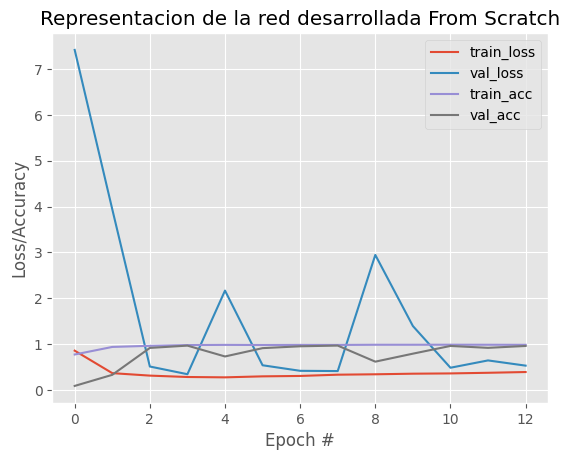

In [63]:
import matplotlib.pyplot as plt
# Codigo
# H sera el resultado de hacer model.fit

# Muestro gráfica de accuracy y losses
num_epochs_trained = len(H.history["loss"])
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, num_epochs_trained), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, num_epochs_trained), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, num_epochs_trained), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, num_epochs_trained), H.history["val_accuracy"], label="val_acc")
plt.title("Representacion de la red desarrollada From Scratch")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()

### Comparacion de resultados de los modelos


In [ ]:
import json

scratch_file = "./content/models/models.json"
pretrain_Resnet_file = "./content/models/models_pretrain_RESNET.json"
pretrain_MobileNetV2_file = "./content/models/models_pretrain_MobileNetV2.json"

# Carregar fitxers
with open(scratch_file, "r") as f:
    scratch_models = json.load(f)

with open(pretrain_Resnet_file, "r") as f:
    pretrain_resnet_models = json.load(f)

with open(pretrain_MobileNetV2_file, "r") as f:
    pretrain_mobilenet_models = json.load(f)

print("\n===  Comparación de modelos ===\n")

def print_model_info(title, info):
    print(f"--- {title} ---")
    for k, v in info.items():
        print(f"{k}: {v}")
    print()

# Obtener mejor modelo de cada categoria
best_scratch = max(scratch_models, key=lambda x: x["results"]["val_accuracy"])
best_resnet = max(pretrain_resnet_models, key=lambda x: x["results"]["val_accuracy_finetune"])
best_mobilenet = max(pretrain_mobilenet_models, key=lambda x: x["results"]["val_accuracy_finetune"])

# Mostrar información
print_model_info("Mejor modelo From Scratch", {
    "fichero": best_scratch["model_filename"],
    "val_accuracy": best_scratch["results"]["val_accuracy"],
    "best_epoch": best_scratch["best_epoch"],
    "hyperparams": {
        "kernel_size": best_scratch["kernel_size"],
        "l2": best_scratch["l2_reg_ratio"],
        "batch_size": best_scratch["batch_size"]
    }
})

print_model_info("Mejor modelo Pretrained ResNet50", {
    "arquitectura": best_resnet["architecture"],
    "val_acc_transfer": best_resnet["results"]["val_accuracy_transfer"],
    "val_acc_finetune": best_resnet["results"]["val_accuracy_finetune"],
    "epochs_TL": best_resnet["transfer_learning_epochs"],
    "epochs_FT": best_resnet["fine_tuning_epochs"],
    "unfreeze_layers": best_resnet["unfreeze_layers"]
})

print_model_info("Mejor modelo Pretrained MobileNetV2", {
    "arquitectura": best_mobilenet["architecture"],
    "val_acc_transfer": best_mobilenet["results"]["val_accuracy_transfer"],
    "val_acc_finetune": best_mobilenet["results"]["val_accuracy_finetune"],
    "epochs_TL": best_mobilenet["transfer_learning_epochs"],
    "epochs_FT": best_mobilenet["fine_tuning_epochs"],
    "unfreeze_layers": best_mobilenet["unfreeze_layers"]
})

# n final
best_overall = max([
    ("From Scratch", best_scratch["results"]["val_accuracy"]),
    ("ResNet50 Pretrained", best_resnet["results"]["val_accuracy_finetune"]),
    ("MobileNetV2 Pretrained", best_mobilenet["results"]["val_accuracy_finetune"])
], key=lambda x: x[1])

print("=== RESULTADO FINAL ===")
print(f" La red mejor es: {best_overall[0]} con val_accuracy = {best_overall[1]:.4f}")


===  Comparación de modelos ===

--- Mejor modelo From Scratch ---
fichero: best_model_20251115_165724.h5
val_accuracy: 0.9663333296775818
best_epoch: 8
hyperparams: {'kernel_size': [3, 3], 'l2': 1e-05, 'batch_size': 64}

--- Mejor modelo Pretrained ResNet50 ---
arquitectura: ResNet50
val_acc_transfer: 1.0
val_acc_finetune: 1.0
epochs_TL: 8
epochs_FT: 6
unfreeze_layers: 50

--- Mejor modelo Pretrained MobileNetV2 ---
arquitectura: ResNet50
val_acc_transfer: 0.9753333330154419
val_acc_finetune: 0.9900000095367432
epochs_TL: 19
epochs_FT: 18
unfreeze_layers: 50

=== RESULTADO FINAL ===
 La red mejor es: ResNet50 Pretrained con val_accuracy = 1.0000


# 6. Evaluación del modelo predictivo y planteamiento de la siguiente prueba experimental

###

### Cosas vistas en clases que hay que realizar (este apartado se borra una vez hecho)

- Utilizar el siguiente código sobre para obtener todas las métricas tipicas de un problema de clasificación, se realiza sobre el conjunto de test (el que nunca se ha usado en entrenamiento):

In [62]:
from sklearn.metrics import classification_report
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

# Buscar el mejor modelo guardado de que comienza con best_model_pretrain_RESNET en la carpeta content/models
best_model_path = None
for filename in os.listdir(MODELS_DIR):
    if filename.startswith("best_model_pretrain_RESNET"):
        best_model_path = os.path.join(MODELS_DIR, filename)
        break



print(f"[INFO]: Cargando modelo desde {best_model_path}")
best_model = load_model(best_model_path)

# RE-DEFINIR test_datagen y test_generator CON EL PREPROCESSING CORRECTO PARA RESNET50
test_datagen_resnet = ImageDataGenerator(preprocessing_function=preprocess_input)

test_generator_resnet = test_datagen_resnet.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    shuffle=False
)


# Evaluando el modelo con el conjunto de test
print("[INFO]: Evaluando red neuronal con conjunto de test...")

# Obtener predicciones
predictions = best_model.predict(test_generator_resnet, verbose=1)

# Obtener las etiquetas reales del generador
y_true = test_generator_resnet.classes

# Obtener las clases predichas
y_pred = predictions.argmax(axis=1)

# Obtener los nombres de las clases
class_names = list(test_generator_resnet.class_indices.keys())

# Generar el classification report
print("\n" + "="*60)
print("CLASSIFICATION REPORT - Conjunto de Test")
print("="*60)
print(classification_report(y_true, y_pred, target_names=class_names))
print("="*60)

[INFO]: Cargando modelo desde ./content/models/best_model_pretrain_RESNET_20251115_172027.h5


Found 3000 images belonging to 15 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


[INFO]: Evaluando red neuronal con conjunto de test...
47/47 ━━━━━━━━━━━━━━━━━━━━ 18s 281ms/step

CLASSIFICATION REPORT - Conjunto de Test
              precision    recall  f1-score   support

        Bean       1.00      1.00      1.00       200
Bitter_Gourd       1.00      0.99      1.00       200
Bottle_Gourd       1.00      1.00      1.00       200
     Brinjal       1.00      0.99      1.00       200
    Broccoli       0.99      1.00      0.99       200
     Cabbage       1.00      1.00      1.00       200
    Capsicum       1.00      1.00      1.00       200
      Carrot       1.00      1.00      1.00       200
 Cauliflower       1.00      0.98      0.99       200
    Cucumber       1.00      1.00      1.00       200
      Papaya       1.00      1.00      1.00       200
      Potato       1.00      1.00      1.00       200
     Pumpkin       1.00      1.00      1.00       200
      Radish       1.00      1.00      1.00       200
      Tomato       1.00      1.00      1.00       

### ANEXOS EXTRA

## Escritura de datos a drive usando BASE_FOLDER

In [ ]:
# Conectamos con nuestro Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Establezco una ruta absoluta a un directorio existente de mi Google Drive
BASE_FOLDER = "/content/drive/MyDrive/VIU/Redes Neuronales/Proyecto programación"

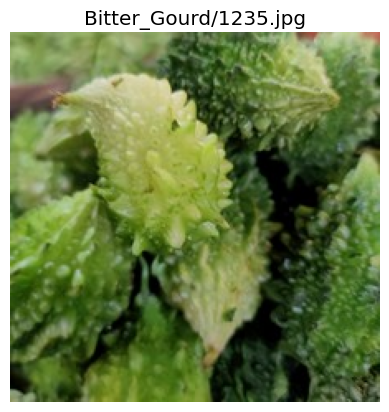

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os

# Escogiendo y mostrando una imagen al azar del conjunto de test
idx = np.random.randint(1, len(test_generator.filenames)) # Use the number of files in test_generator
image_filename = test_generator.filenames[idx]

img_path = os.path.join(TEST_DIR, image_filename)

# Leer imagen. cv2.imread por default en BGR.
img = cv2.imread(img_path)

# Validar imagen
if img is not None:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.title(image_filename) # Titulo
    plt.axis('off')
    plt.show()
else:
    print(f"Error: No se pudo cargar imagen {img_path}")

In [ ]:
# Craer carpeta BASE_FOLDER si no existe
os.makedirs(BASE_FOLDER, exist_ok=True)


# Almacenando una imagen aleatoria de test en mi BASE_FOLDER
cv2.imwrite(BASE_FOLDER + '//un_vegetal.png', img)

True

Copiar la carpeta models al drive de google

In [ ]:
# Copiar toda la carpeta /content/models a $BASE_FOLDER
!cp -r "{MODELS_DIR}" "{BASE_FOLDER}"
print(f"[INFO]: Carpeta de modelos copiada a: {BASE_FOLDER}/models")

[INFO]: Carpeta de modelos copiada a: /content/drive/MyDrive/VIU/Redes Neuronales/Proyecto programación/models


## Ejemplo de generación de documento PDF a partir del Colab Notebook (fichero ".ipynb")

In [ ]:
# Ejecutando los siguientes comandos en la última celda del Colab Notebook se convierte de ".ipynb" a PDF
# En caso de querer ocultar la salida de una celda puesto que no tenga relevancia se debe insertar
# el comando %%capture al inicio de la misma. Véase la celda que contiene !ls test en este Notebook.

In [ ]:
name_IPYNB_file = '07MIAR_Proyecto_Programacion.ipynb'
get_ipython().system(
        "apt update >> /dev/null && apt install texlive-xetex texlive-fonts-recommended texlive-generic-recommended >> /dev/null"
    )
get_ipython().system(
            "jupyter nbconvert --output-dir='$BASE_FOLDER' '$BASE_FOLDER''$name_IPYNB_file' --to pdf"
        )

In [ ]:
# Generate PDF from this notebook
get_ipython().system("jupyter nbconvert --to html --output-dir . *.ipynb")